# Stage 4 — Exploratory Data Analysis

EDA examines the target distribution, availability, missingness, exploratory correlations, outliers, and a descriptive COVID-period timeline. These analyses help understand the data before final model training.

## 4.1 U5MR availability over time

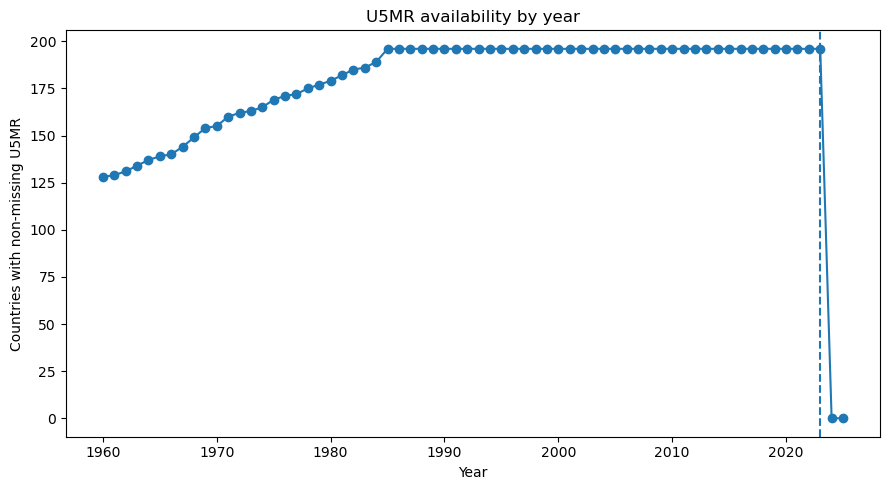

In [642]:
plt.figure(figsize=(9, 5))
plt.plot(u5mr_availability["year"], u5mr_availability["available_countries"], marker="o")
plt.axvline(TARGET_YEAR, linestyle="--")
plt.title("U5MR availability by year")
plt.xlabel("Year")
plt.ylabel("Countries with non-missing U5MR")
plt.tight_layout()
plt.savefig(VIS_DIR / "u5mr_availability_by_year.png", dpi=300)
plt.show()

## 4.2 Target distribution: U5MR 2023

count    196.000000
mean      24.658673
std       24.978019
min        1.400000
25%        6.100000
50%       15.350000
75%       38.350000
max      114.800000
Name: u5mr_2023, dtype: float64

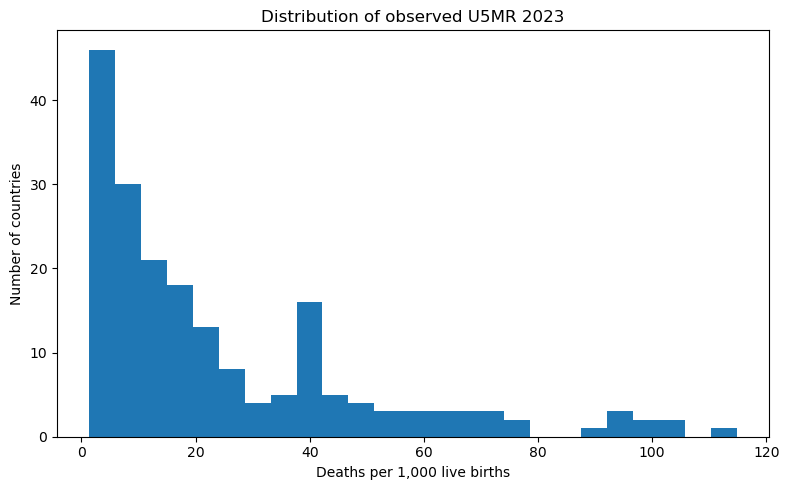

In [644]:
display(target_df["u5mr_2023"].describe())

plt.figure(figsize=(8, 5))
plt.hist(target_df["u5mr_2023"], bins=25)
plt.title("Distribution of observed U5MR 2023")
plt.xlabel("Deaths per 1,000 live births")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig(VIS_DIR / "target_u5mr_2023_distribution.png", dpi=300)
plt.show()

## 4.3 Log target distribution

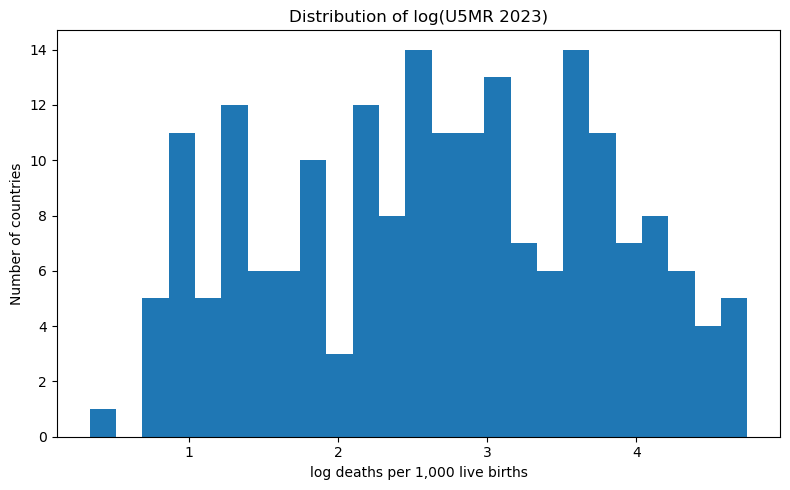

In [646]:
plt.figure(figsize=(8, 5))
plt.hist(target_df["log_u5mr_2023"], bins=25)
plt.title("Distribution of log(U5MR 2023)")
plt.xlabel("log deaths per 1,000 live births")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.savefig(VIS_DIR / "target_log_u5mr_2023_distribution.png", dpi=300)
plt.show()

## 4.4 Highest and lowest U5MR countries

In [648]:
print("Highest U5MR countries")
display(target_df.sort_values("u5mr_2023", ascending=False).head(15))

print("Lowest U5MR countries")
display(target_df.sort_values("u5mr_2023", ascending=True).head(15))

Highest U5MR countries


,country_code,country_name,u5mr_2023,log_u5mr_2023
1,NER,Niger,114.8,4.743191
189,NGA,Nigeria,104.9,4.653008
124,SOM,"Somalia, Federal Republic of",104.0,4.644391
159,TCD,Chad,101.1,4.616110
2,SSD,South Sudan,98.7,4.592085
80,GIN,Guinea,95.0,4.553877
170,SLE,Sierra Leone,94.3,4.546481
169,CAF,Central African Republic,92.2,4.523960
107,MLI,Mali,91.3,4.514151
73,BEN,Benin,77.9,4.355426


Lowest U5MR countries


,country_code,country_name,u5mr_2023,log_u5mr_2023
187,SMR,San Marino,1.4,0.336472
94,EST,Estonia,2.1,0.741937
70,SGP,Singapore,2.1,0.741937
66,SVN,Slovenia,2.2,0.788457
128,LUX,Luxembourg,2.3,0.832909
178,FIN,Finland,2.3,0.832909
109,JPN,Japan,2.4,0.875469
185,NOR,Norway,2.4,0.875469
93,BLR,Belarus,2.4,0.875469
140,SWE,Sweden,2.5,0.916291


## 4.5 Helper functions for 2022 values and 5-year changes

In [650]:
def most_recent_pre_target_values(wide_df, years, value_name="most_recent_value"):
    """Return the most recent observed value within the supplied years for each country-indicator pair.

    This helper is used mainly for EDA because it gives broad coverage.
    The final model below uses the explicit 2022 value instead of a 'most recent' feature name.
    """
    selected_year_cols = [str(y) for y in years]
    long_df = wide_df[
        ["country_code", "country_name", "indicator_code", "indicator_name"] + selected_year_cols
    ].melt(
        id_vars=["country_code", "country_name", "indicator_code", "indicator_name"],
        var_name="source_year",
        value_name="value"
    )
    long_df["source_year"] = long_df["source_year"].astype(int)
    long_df = long_df.dropna(subset=["value"]).sort_values(["country_code", "indicator_code", "source_year"])
    most_recent_df = long_df.groupby(["country_code", "country_name", "indicator_code", "indicator_name"], as_index=False).tail(1)
    most_recent_df = most_recent_df.rename(columns={"value": value_name})
    return most_recent_df


def fixed_year_values(wide_df, year, value_name=None):
    """Return the exact value for a single year for each country-indicator pair.

    This is used for final modeling so feature names can show the year explicitly,
    for example water_access_2022.
    """
    year_col = str(year)
    if year_col not in wide_df.columns:
        raise ValueError(f"Year column {year_col} is not available.")
    if value_name is None:
        value_name = f"value_{year}"

    output = wide_df[["country_code", "country_name", "indicator_code", "indicator_name", year_col]].copy()
    output = output.rename(columns={year_col: value_name})
    output["source_year"] = int(year)
    output = output.dropna(subset=[value_name])
    return output


def five_year_change_values(wide_df, years):
    """Return most recent minus earliest observed value within the recent pre-target window.

    This is kept for exploratory checks. The final model uses the exact 2018-to-2022 change.
    """
    selected_year_cols = [str(y) for y in years]
    long_df = wide_df[
        ["country_code", "country_name", "indicator_code", "indicator_name"] + selected_year_cols
    ].melt(
        id_vars=["country_code", "country_name", "indicator_code", "indicator_name"],
        var_name="source_year",
        value_name="value"
    )
    long_df["source_year"] = long_df["source_year"].astype(int)
    long_df = long_df.dropna(subset=["value"]).sort_values(["country_code", "indicator_code", "source_year"])

    first_df = long_df.groupby(["country_code", "indicator_code"], as_index=False).first()[
        ["country_code", "indicator_code", "source_year", "value"]
    ].rename(columns={"source_year": "change_start_year", "value": "change_start_value"})

    last_df = long_df.groupby(["country_code", "indicator_code"], as_index=False).last()[
        ["country_code", "indicator_code", "source_year", "value"]
    ].rename(columns={"source_year": "change_end_year", "value": "change_end_value"})

    meta = long_df[["country_code", "country_name", "indicator_code", "indicator_name"]].drop_duplicates(
        subset=["country_code", "indicator_code"]
    )

    change_df = first_df.merge(last_df, on=["country_code", "indicator_code"], how="inner")
    change_df = change_df.merge(meta, on=["country_code", "indicator_code"], how="left")
    change_df["change5y_value"] = change_df["change_end_value"] - change_df["change_start_value"]
    return change_df


def exact_change_between_years(wide_df, start_year, end_year):
    """Return exact end-year value minus exact start-year value.

    For this project, the final trend feature is value_2022 - value_2018.
    Countries missing either endpoint are treated as missing for the change feature.
    """
    start_col = str(start_year)
    end_col = str(end_year)
    for col in [start_col, end_col]:
        if col not in wide_df.columns:
            raise ValueError(f"Year column {col} is not available.")

    output = wide_df[["country_code", "country_name", "indicator_code", "indicator_name", start_col, end_col]].copy()
    output = output.rename(columns={
        start_col: "change_start_value",
        end_col: "change_end_value"
    })
    output["change_start_year"] = int(start_year)
    output["change_end_year"] = int(end_year)
    output[f"change_{start_year}_{end_year}"] = output["change_end_value"] - output["change_start_value"]
    output = output.dropna(subset=[f"change_{start_year}_{end_year}"])
    return output

## 4.6 Most recent pre-2023 values for EDA

In [652]:
most_recent_pre2023_eda = most_recent_pre_target_values(country_wdi, PREDICTOR_YEARS)
most_recent_pre2023_eda = most_recent_pre2023_eda[most_recent_pre2023_eda["country_code"].isin(target_df["country_code"])].copy()

print("Most recent pre-2023 country-indicator observations:", most_recent_pre2023_eda.shape)

Most recent pre-2023 country-indicator observations: (234423, 6)


## 4.7 Indicator missingness landscape

,indicator_code,indicator_name,observed_countries,median_source_year,missing_countries,missing_pct
1315,WB_WDI_SP_POP_2529_MA_5Y,"Population ages 25-29, male (% of male populat...",196,2022.0,0,0.0
1298,WB_WDI_SP_POP_0014_TO,"Population ages 0-14, total",196,2022.0,0,0.0
1257,WB_WDI_SM_POP_NETM,Net migration,196,2022.0,0,0.0
1297,WB_WDI_SP_POP_0014_MA_ZS,"Population ages 0-14, male (% of male population)",196,2022.0,0,0.0
1296,WB_WDI_SP_POP_0014_MA_IN,"Population ages 0-14, male",196,2022.0,0,0.0
1307,WB_WDI_SP_POP_1564_FE_ZS,"Population ages 15-64, female (% of female pop...",196,2022.0,0,0.0
1295,WB_WDI_SP_POP_0014_FE_ZS,"Population ages 0-14, female (% of female popu...",196,2022.0,0,0.0
1294,WB_WDI_SP_POP_0014_FE_IN,"Population ages 0-14, female",196,2022.0,0,0.0
1293,WB_WDI_SP_POP_0004_MA_5Y,"Population ages 00-04, male (% of male populat...",196,2022.0,0,0.0
1271,WB_WDI_SP_ADO_TFRT,"Adolescent fertility rate (births per 1,000 wo...",196,2022.0,0,0.0


count    1468.000000
mean        0.185262
std         0.206561
min         0.000000
25%         0.035714
50%         0.102041
75%         0.246173
max         0.994898
Name: missing_pct, dtype: float64

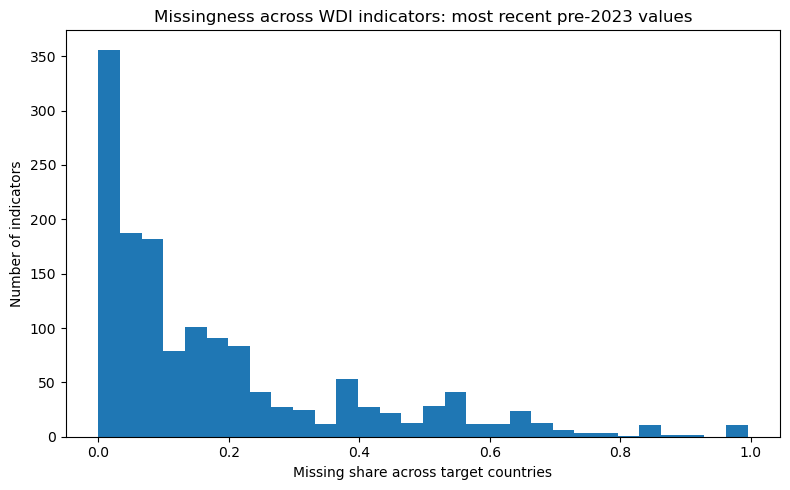

In [654]:
target_country_count = target_df["country_code"].nunique()

indicator_missingness = (
    most_recent_pre2023_eda
    .groupby(["indicator_code", "indicator_name"], as_index=False)
    .agg(
        observed_countries=("most_recent_value", "count"),
        median_source_year=("source_year", "median")
    )
)

indicator_missingness["missing_countries"] = target_country_count - indicator_missingness["observed_countries"]
indicator_missingness["missing_pct"] = indicator_missingness["missing_countries"] / target_country_count
indicator_missingness = indicator_missingness.sort_values("missing_pct")

indicator_missingness.to_csv(TABLE_DIR / "indicator_missingness_pre2023.csv", index=False)

display(indicator_missingness.head(10))

display(indicator_missingness["missing_pct"].describe())

plt.figure(figsize=(8, 5))
plt.hist(indicator_missingness["missing_pct"], bins=30)
plt.title("Missingness across WDI indicators: most recent pre-2023 values")
plt.xlabel("Missing share across target countries")
plt.ylabel("Number of indicators")
plt.tight_layout()
plt.savefig(VIS_DIR / "indicator_missingness_distribution.png", dpi=300)
plt.show()

## 4.8 Exploratory correlations with log U5MR

In [656]:
merged_for_eda_corr = most_recent_pre2023_eda.merge(
    target_df[["country_code", "log_u5mr_2023"]],
    on="country_code",
    how="inner"
)

corr_rows = []
for (code_value, name_value), group in merged_for_eda_corr.groupby(["indicator_code", "indicator_name"]):
    valid = group[["most_recent_value", "log_u5mr_2023"]].dropna()
    if len(valid) >= 50 and valid["most_recent_value"].nunique() > 1:
        corr_value = valid["most_recent_value"].corr(valid["log_u5mr_2023"], method="spearman")
    else:
        corr_value = np.nan
    corr_rows.append({
        "indicator_code": code_value,
        "indicator_name": name_value,
        "eda_spearman_corr": corr_value,
        "abs_corr": abs(corr_value) if pd.notna(corr_value) else np.nan,
        "valid_pairs": len(valid)
    })

eda_correlations = pd.DataFrame(corr_rows).merge(
    indicator_missingness[["indicator_code", "missing_pct"]],
    on="indicator_code",
    how="left"
)

eda_correlations.to_csv(TABLE_DIR / "eda_spearman_correlations_pre2023.csv", index=False)

print("Strongest negative correlations")
display(eda_correlations.dropna().sort_values("eda_spearman_corr").head(12)[
    ["indicator_name", "missing_pct", "eda_spearman_corr", "valid_pairs"]
])

print("Strongest positive correlations")
display(eda_correlations.dropna().sort_values("eda_spearman_corr", ascending=False).head(12)[
    ["indicator_name", "missing_pct", "eda_spearman_corr", "valid_pairs"]
])

Strongest negative correlations


,indicator_name,missing_pct,eda_spearman_corr,valid_pairs
1281,"Life expectancy at birth, female (years)",0.000000,-0.923137,196
417,Human capital index plus (HCI+): overall score...,0.132653,-0.909149,170
406,Human capital index plus (HCI+): education pil...,0.132653,-0.905786,170
416,Human capital index plus (HCI+): overall score...,0.158163,-0.902923,165
1285,"Survival to age 65, female (% of cohort)",0.000000,-0.902693,196
1282,"Life expectancy at birth, total (years)",0.000000,-0.901748,196
1003,Lifetime risk of maternal death (1 in: rate va...,0.015306,-0.901746,193
409,Human capital index plus (HCI+): health pillar...,0.010204,-0.901562,194
1119,"Survey mean consumption or income per capita, ...",0.372449,-0.897936,123
408,Human capital index plus (HCI+): education pil...,0.107143,-0.897166,175


Strongest positive correlations


,indicator_name,missing_pct,eda_spearman_corr,valid_pairs
965,"Mortality rate, under-5 (per 1,000 live births)",0.000000,0.995093,196
966,"Mortality rate, under-5, female (per 1,000 liv...",0.000000,0.994514,196
967,"Mortality rate, under-5, male (per 1,000 live ...",0.000000,0.994482,196
1280,"Mortality rate, infant, male (per 1,000 live b...",0.000000,0.990627,196
1279,"Mortality rate, infant (per 1,000 live births)",0.000000,0.990622,196
1278,"Mortality rate, infant, female (per 1,000 live...",0.000000,0.989790,196
971,"Mortality rate, neonatal (per 1,000 live births)",0.000000,0.983000,196
959,Probability of dying among children ages 5-9 y...,0.000000,0.947803,196
960,Probability of dying among adolescents ages 10...,0.000000,0.933682,196
1004,Lifetime risk of maternal death (%),0.015306,0.901664,193


## 4.9 U5MR outlier inspection

In [658]:
q1 = target_df["u5mr_2023"].quantile(0.25)
q3 = target_df["u5mr_2023"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

outliers = target_df[target_df["u5mr_2023"] > upper_fence].sort_values("u5mr_2023", ascending=False)

print("IQR upper fence:", round(upper_fence, 2))
print("Countries flagged as high-U5MR outliers:", len(outliers))
display(outliers)

outliers.to_csv(TABLE_DIR / "u5mr_2023_high_outliers_iqr.csv", index=False)

IQR upper fence: 86.72
Countries flagged as high-U5MR outliers: 9


,country_code,country_name,u5mr_2023,log_u5mr_2023
1,NER,Niger,114.8,4.743191
189,NGA,Nigeria,104.9,4.653008
124,SOM,"Somalia, Federal Republic of",104.0,4.644391
159,TCD,Chad,101.1,4.616110
2,SSD,South Sudan,98.7,4.592085
80,GIN,Guinea,95.0,4.553877
170,SLE,Sierra Leone,94.3,4.546481
169,CAF,Central African Republic,92.2,4.523960
107,MLI,Mali,91.3,4.514151


## 4.10 Example scatter plots

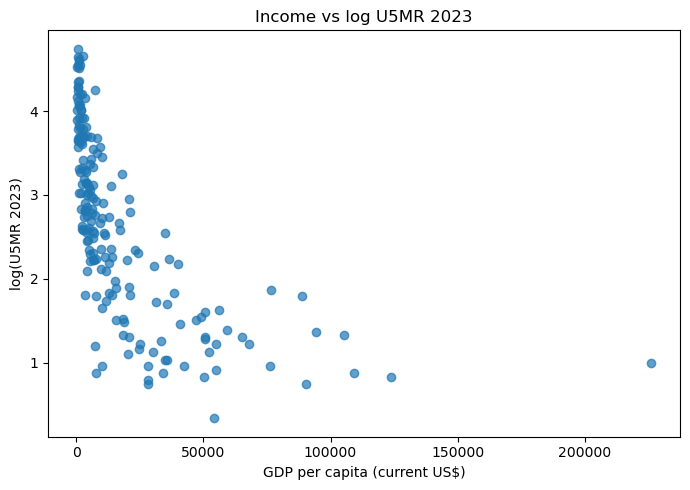

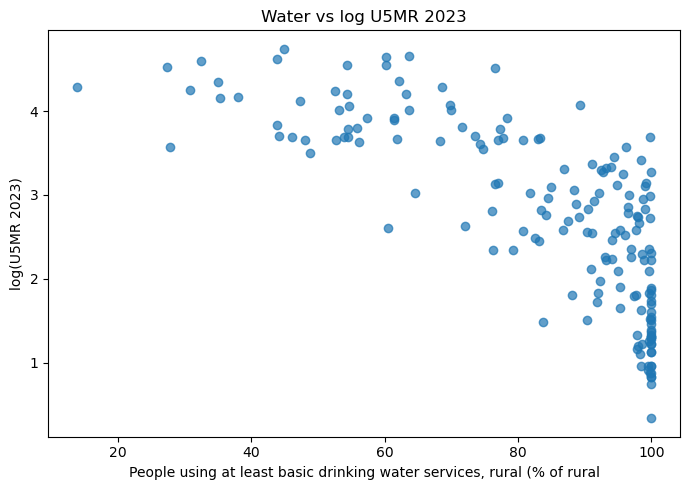

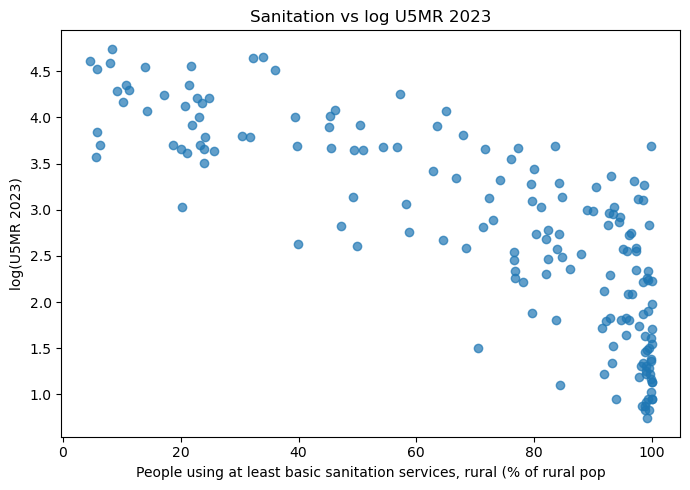

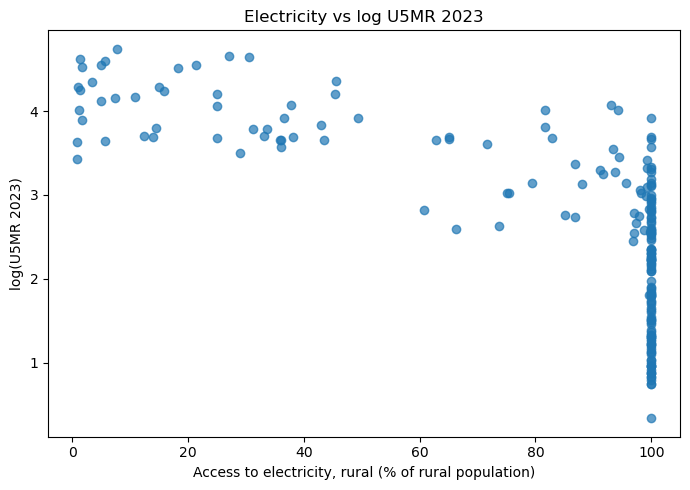

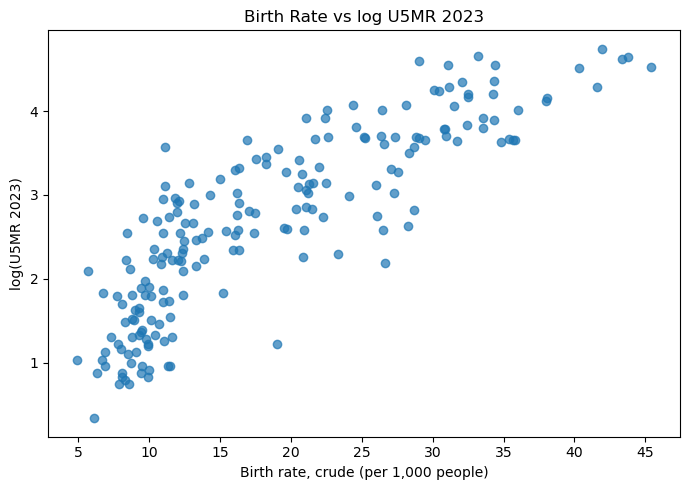

In [660]:
def find_indicator_by_keywords(indicator_table, keyword_options):
    names = indicator_table[["indicator_code", "indicator_name"]].drop_duplicates().copy()
    names["name_lower"] = names["indicator_name"].str.lower()
    for keywords in keyword_options:
        keywords = [kw.lower() for kw in keywords]
        mask = names["name_lower"].apply(lambda value: all(kw in value for kw in keywords))
        matches = names[mask]
        if len(matches) > 0:
            return matches.iloc[0]["indicator_code"], matches.iloc[0]["indicator_name"]
    return None, None

scatter_specs = {
    "income": [["gdp per capita"], ["gni per capita"], ["income per capita", "bottom 40"]],
    "water": [["basic drinking water", "population"]],
    "sanitation": [["basic sanitation", "population"]],
    "electricity": [["access to electricity"]],
    "birth_rate": [["birth rate", "crude"]]
}

for short_name, keyword_options in scatter_specs.items():
    code_value, name_value = find_indicator_by_keywords(indicator_inventory, keyword_options)
    if code_value is None:
        print(f"No matching indicator found for {short_name}.")
        continue

    plot_df = most_recent_pre2023_eda[most_recent_pre2023_eda["indicator_code"] == code_value].merge(
        target_df[["country_code", "log_u5mr_2023"]],
        on="country_code",
        how="inner"
    ).dropna(subset=["most_recent_value", "log_u5mr_2023"])

    if len(plot_df) < 30:
        continue

    plt.figure(figsize=(7, 5))
    plt.scatter(plot_df["most_recent_value"], plot_df["log_u5mr_2023"], alpha=0.7)
    plt.title(f"{short_name.replace('_', ' ').title()} vs log U5MR 2023")
    plt.xlabel(name_value[:70])
    plt.ylabel("log(U5MR 2023)")
    plt.tight_layout()
    plt.savefig(VIS_DIR / f"scatter_{short_name}_log_u5mr.png", dpi=300)
    plt.show()

## 4.11 Descriptive COVID-period U5MR timeline

This is an exploratory timeline, not a causal COVID impact analysis. U5MR values in WDI often move gradually and may be estimate-based rather than direct annual counts. Therefore, this section asks a descriptive question only:

**Was the U5MR level during the COVID period visibly higher than the surrounding pre-COVID and post-COVID periods?**

Periods used here:

- **Pre-COVID:** 2015–2019
- **COVID period:** 2020–2021
- **Post-COVID / most recent observed period:** 2022–2023

,year,median_u5mr,mean_u5mr,countries
0,2015,18.25,31.408673,196
1,2016,17.70,30.673980,196
2,2017,17.10,30.211735,196
3,2018,16.45,28.440816,196
4,2019,16.20,28.167857,196
5,2020,15.65,26.718878,196
6,2021,15.15,26.241837,196
7,2022,14.70,26.838776,196
8,2023,15.35,24.658673,196


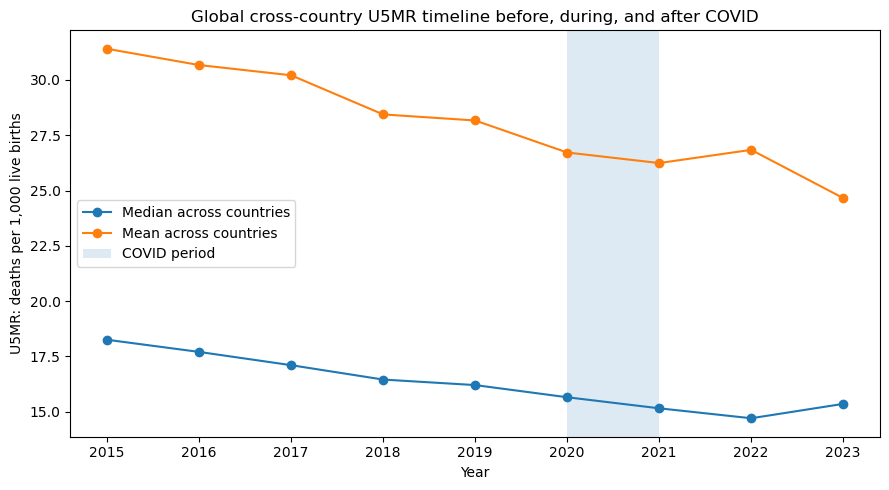

In [662]:
covid_years = list(range(2015, TARGET_YEAR + 1))
u5mr_timeline = u5mr_wide[["country_code", "country_name"] + [str(y) for y in covid_years]].melt(
    id_vars=["country_code", "country_name"],
    var_name="year",
    value_name="u5mr"
)
u5mr_timeline["year"] = u5mr_timeline["year"].astype(int)
u5mr_timeline = u5mr_timeline.dropna(subset=["u5mr"])

global_timeline = (
    u5mr_timeline
    .groupby("year", as_index=False)
    .agg(
        median_u5mr=("u5mr", "median"),
        mean_u5mr=("u5mr", "mean"),
        countries=("country_code", "nunique")
    )
)

global_timeline.to_csv(TABLE_DIR / "u5mr_covid_timeline_global.csv", index=False)
display(global_timeline)

plt.figure(figsize=(9, 5))
plt.plot(global_timeline["year"], global_timeline["median_u5mr"], marker="o", label="Median across countries")
plt.plot(global_timeline["year"], global_timeline["mean_u5mr"], marker="o", label="Mean across countries")
plt.axvspan(2020, 2021, alpha=0.15, label="COVID period")
plt.title("Global cross-country U5MR timeline before, during, and after COVID")
plt.xlabel("Year")
plt.ylabel("U5MR: deaths per 1,000 live births")
plt.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / "u5mr_timeline_before_during_after_covid.png", dpi=300)
plt.show()

## 4.12 Compare pre-COVID, COVID, and post-COVID country averages

,count,mean,std,min,25%,50%,75%,max
period,,,,,,,,
pre_covid_2015_2019,196.0,29.780612,32.591280,1.82,7.3450,17.130,45.5350,201.96
covid_2020_2021,196.0,26.480357,27.802460,1.55,6.5000,15.575,42.0750,146.95
post_covid_2022_2023,196.0,25.748724,29.520891,1.45,6.1375,15.500,39.1625,239.80
covid_minus_pre,196.0,-3.300255,7.988572,-103.26,-4.1850,-1.535,-0.3450,4.75
post_minus_covid,196.0,-0.731633,7.043025,-7.25,-2.0625,-0.650,-0.1500,92.85


C:\Users\ayoub\AppData\Local\Temp\ipykernel_13840\1975163887.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=["Pre-COVID\n2015–2019", "COVID\n2020–2021", "Post-COVID\n2022–2023"])


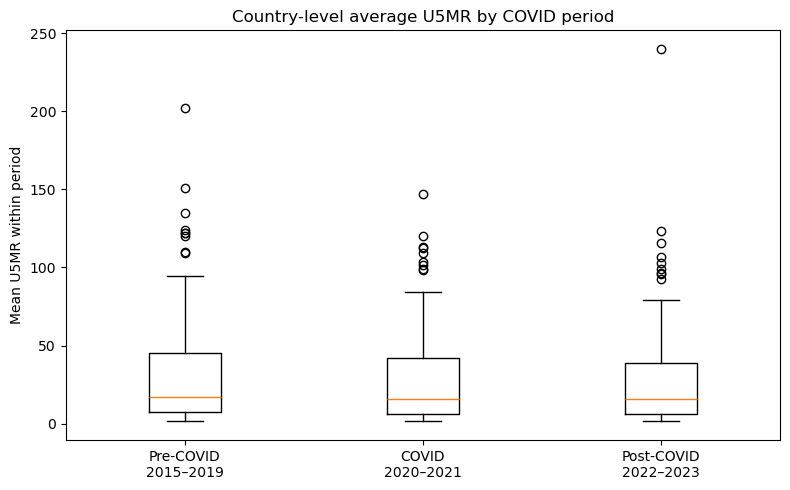

In [664]:
def assign_covid_period(year):
    if 2015 <= year <= 2019:
        return "pre_covid_2015_2019"
    if 2020 <= year <= 2021:
        return "covid_2020_2021"
    if 2022 <= year <= 2023:
        return "post_covid_2022_2023"
    return np.nan

period_df = u5mr_timeline.copy()
period_df["period"] = period_df["year"].apply(assign_covid_period)
period_df = period_df.dropna(subset=["period"])

country_period = (
    period_df
    .groupby(["country_code", "country_name", "period"], as_index=False)
    .agg(mean_u5mr=("u5mr", "mean"))
)

period_wide = country_period.pivot_table(
    index=["country_code", "country_name"],
    columns="period",
    values="mean_u5mr"
).reset_index()

period_columns = ["pre_covid_2015_2019", "covid_2020_2021", "post_covid_2022_2023"]
period_wide = period_wide.dropna(subset=period_columns)
period_wide["covid_minus_pre"] = period_wide["covid_2020_2021"] - period_wide["pre_covid_2015_2019"]
period_wide["post_minus_covid"] = period_wide["post_covid_2022_2023"] - period_wide["covid_2020_2021"]

period_summary = period_wide[period_columns + ["covid_minus_pre", "post_minus_covid"]].describe().T
period_summary.to_csv(TABLE_DIR / "u5mr_covid_period_comparison_summary.csv")
period_wide.to_csv(TABLE_DIR / "u5mr_covid_period_country_comparison.csv", index=False)

display(period_summary)

plot_period_long = period_wide.melt(
    id_vars=["country_code", "country_name"],
    value_vars=period_columns,
    var_name="period",
    value_name="mean_u5mr"
)

plt.figure(figsize=(8, 5))
plot_data = [plot_period_long.loc[plot_period_long["period"] == p, "mean_u5mr"] for p in period_columns]
plt.boxplot(plot_data, labels=["Pre-COVID\n2015–2019", "COVID\n2020–2021", "Post-COVID\n2022–2023"])
plt.title("Country-level average U5MR by COVID period")
plt.ylabel("Mean U5MR within period")
plt.tight_layout()
plt.savefig(VIS_DIR / "u5mr_boxplot_covid_periods.png", dpi=300)
plt.show()

### COVID-period interpretation note

The COVID-period comparison is useful context for the project, but it should remain in EDA. It should not replace the main research question, which is cross-sectional prediction of U5MR 2023 from lagged WDI indicators.

The timeline should also be interpreted cautiously because WDI U5MR values are annual country-level estimates and may be smoothed over time. A gradual trend during 2020–2023 therefore does not prove that the pandemic had no effect on child mortality. The analysis is descriptive, not causal.